In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *
from MODELS.ngboostModel import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s20 = add_volatility_features(s20)
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s21 = add_volatility_features(s21)
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s22 = add_volatility_features(s22)
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s23 = add_volatility_features(s23)
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24 = add_volatility_features(s24)
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25 = add_volatility_features(s25)
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
s26 = add_volatility_features(s26)

def cap_outliers_per_player(df, target_col='PTS', p_low=0.01, p_high=0.99):
    """Cap target values at specified percentiles per player."""
    df_capped = df.copy()
    for player_id in df_capped['PLAYER_ID'].unique():
        mask = df_capped['PLAYER_ID'] == player_id
        p_low_val = df_capped.loc[mask, target_col].quantile(p_low)
        p_high_val = df_capped.loc[mask, target_col].quantile(p_high)
        df_capped.loc[mask, target_col] = df_capped.loc[mask, target_col].clip(p_low_val, p_high_val)
        print(f"Player {player_id}: PTS range capped [{p_low_val:.1f}, {p_high_val:.1f}]")
    return df_capped

# Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25,s26])
train_df = train_df[train_df['MIN'] > 10]  
train_df = cap_outliers_per_player(train_df, 'PTS', p_low=0.01, p_high=0.99)

# Validation data
# val_df = s25
# val_df = val_df[val_df['MIN'] > 10] 
# val_df = cap_outliers_per_player(val_df, 'PTS', p_low=0.01, p_high=0.99)

print(f"Train set: {len(train_df)} samples")
# print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")
train_df.sample(5)

Player 1713: PTS range capped [0.0, 16.0]
Player 2199: PTS range capped [0.0, 9.7]
Player 2544: PTS range capped [10.6, 46.4]
Player 2546: PTS range capped [1.9, 29.0]
Player 2594: PTS range capped [0.0, 20.9]
Player 2617: PTS range capped [0.0, 23.0]
Player 2730: PTS range capped [0.0, 21.0]
Player 2738: PTS range capped [0.0, 12.8]
Player 2747: PTS range capped [0.1, 10.8]
Player 2772: PTS range capped [0.0, 21.0]
Player 101107: PTS range capped [0.0, 21.5]
Player 101108: PTS range capped [0.0, 30.0]
Player 101133: PTS range capped [2.0, 23.6]
Player 101139: PTS range capped [0.0, 20.5]
Player 101141: PTS range capped [0.0, 18.8]
Player 101150: PTS range capped [1.8, 32.4]
Player 200746: PTS range capped [1.2, 37.7]
Player 200752: PTS range capped [0.0, 22.0]
Player 200755: PTS range capped [0.0, 31.0]
Player 200757: PTS range capped [0.0, 9.0]
Player 200765: PTS range capped [0.0, 20.3]
Player 200768: PTS range capped [0.0, 32.0]
Player 200782: PTS range capped [0.0, 18.2]
Player 20

,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS_AVG_TO_DATE,MATCHUP_PTS_DELTA,MATCHUP_A

In [ ]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'IS_STARTER_TIER', 
    'IS_ROLE_TIER', 
    'IS_BENCH_TIER', 
    'STARTING_X_BENCH_TIER', 
    'STARTING_X_ROLE_TIER', 
    'GUARD',
    'FORWARD',
    'CENTER',
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',

    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',  
    'PTS_ROLLING_AVG_40', 
    'PTS_TREND_LAST_5', 
    'MIN_TREND_LAST_5', 
    'PTS_PER_MIN_X_USG',
    'PTS_VOLATILITY_5_TO_DATE', 
    # 'PTS_EXTREME_VOLATILITY',
    # 'PTS_RECENT_HIGH_VOLATILITY',
    'FGA_LAG_1',
    'FGM_VOLATILITY_5_TO_DATE', 
    'FGA_VOLATILITY_5_TO_DATE', 
    '3PA_RATE',
    'USG_PCT_LAG_1',
    'USG_PCT_CV_5_TO_DATE',
    'TS_PCT_CV_5_TO_DATE', 
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_5',
    'TOV_ROLLING_AVG_5',
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'USG_PCT_AVG_TO_DATE',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'PTS_PER_MIN_X_MIN_LAG',
    'USAGE_X_EFFICIENCY', 
    'PTS_PER_POSSESSION', 
    'PACE_VOLATILITY_5_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_5_TO_DATE', 
    'NET_RATING_VOLATILITY_5_TO_DATE', 
    'FG_PCT_CV_5_TO_DATE', 
    'FG3A_VOLATILITY_5_TO_DATE', 
    'FG3M_VOLATILITY_5_TO_DATE', 
    'FG3_PCT_CV_5_TO_DATE', 
    'FTA_VOLATILITY_5_TO_DATE', 
    'FTM_VOLATILITY_5_TO_DATE', 
    'FT_PCT_CV_5_TO_DATE',
    'TOV_VOLATILITY_5_TO_DATE',
    'FGA_ROLLING_AVG_10', 
    'EXPECTED_USAGE_MIN', 
    
    'TEAM_PACE_ELITE', 
    'TEAM_PACE_GOOD',
    'TEAM_PACE_AVERAGE',
    'TEAM_PACE_POOR',
    'TEAM_OFF_ELITE',
    'TEAM_OFF_GOOD',
    'TEAM_OFF_AVERAGE',
    'TEAM_OFF_POOR',
    'TEAM_DEF_ELITE',
    'TEAM_DEF_GOOD',
    'TEAM_DEF_AVERAGE',
    'TEAM_DEF_POOR',
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',

    'OPP_PACE_ELITE', 
    'OPP_PACE_GOOD',
    'OPP_PACE_AVERAGE',
    'OPP_PACE_POOR',
    'OPP_OFF_ELITE',
    'OPP_OFF_GOOD',
    'OPP_OFF_AVERAGE',
    'OPP_OFF_POOR',
    'OPP_DEF_ELITE',
    'OPP_DEF_GOOD',
    'OPP_DEF_AVERAGE',
    'OPP_DEF_POOR',
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_GUARD_3PT_DEF_ALLOWED', 
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',

    'OPP_FORWARD_DEF_RATING',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_FORWARD_3PT_DEF_ALLOWED', 
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',

    'OPP_CENTER_DEF_RATING',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_CENTER_3PT_DEF_ALLOWED', 
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',

    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    # 'PACE_ADJUSTED_EXPECTED_PTS', 

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PTS_BASELINE_x_HOME', 
    'MATCHUP_AVG_PTS_TO_DATE',
    'GAMES_VS_OPP' 
 ]

In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=70,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

Selected 70 total features
Top 10 most important:
1. PTS_ROLLING_AVG_40
2. PTS_BASELINE
3. PTS_AVG_TO_DATE
4. USG_X_STARTER_TIER
5. STARTING_X_STARTER_TIER
6. PLAYER_PTS_SHARE
7. FGA_ROLLING_AVG_10
8. EXPECTED_USAGE_MIN
9. PTS_X_OPP_DEF_RATING
10. PTS_X_STARTER_TIER


# XGBOOST MODEL

### Remove correlated features

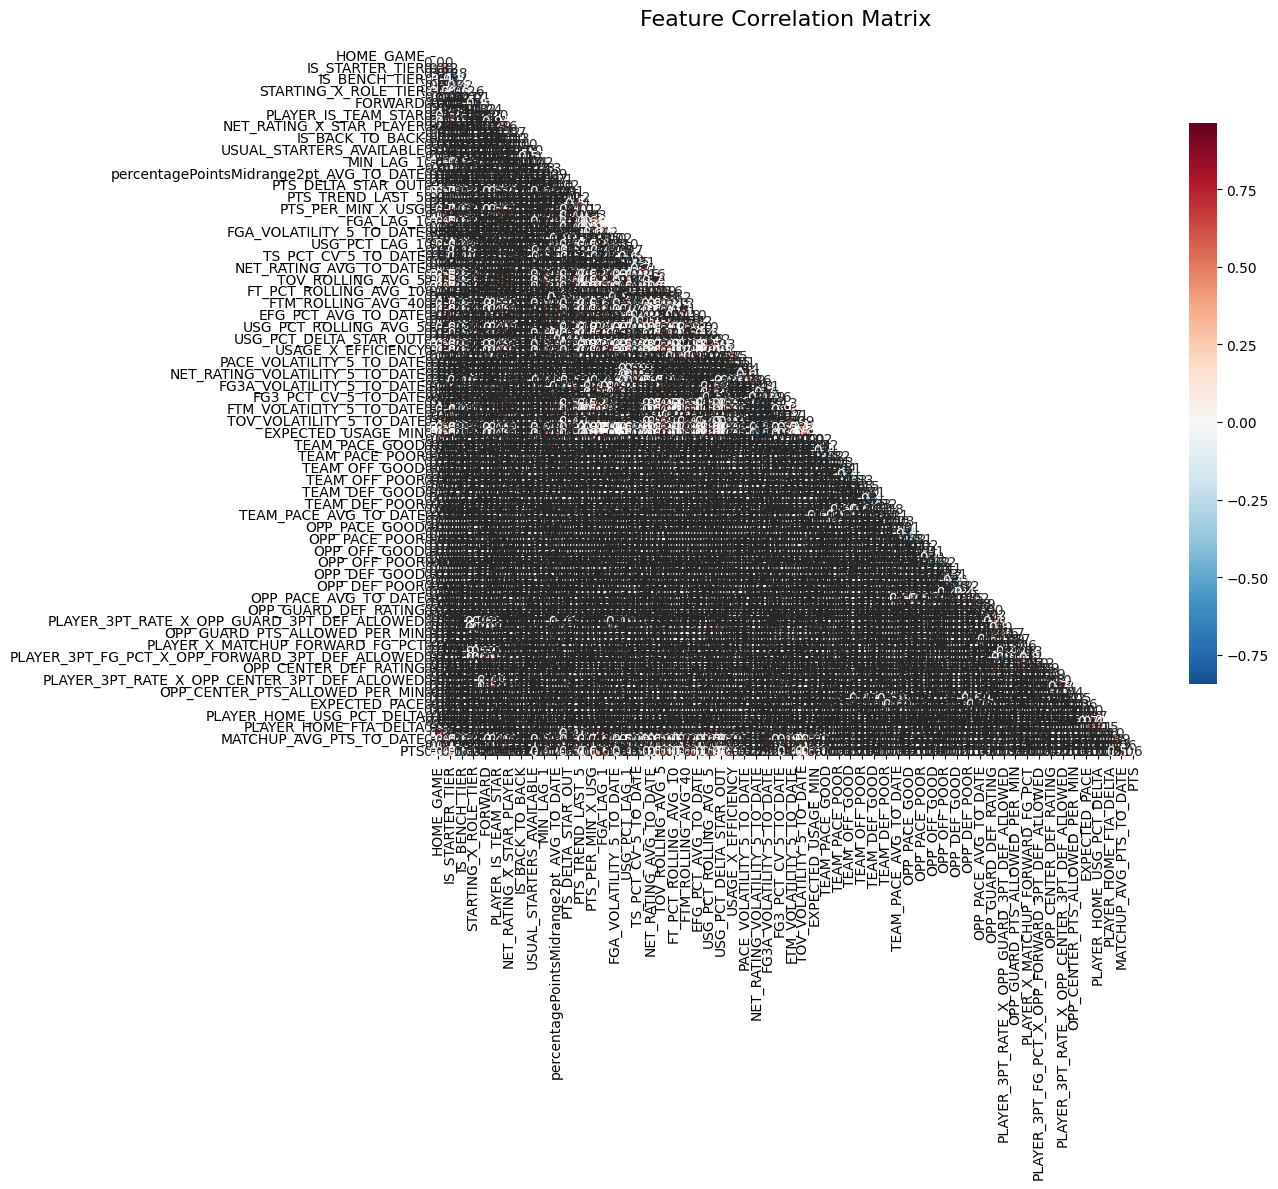

TOP 10 FEATURES MOST CORRELATED WITH TARGET:
 1. PTS_ROLLING_AVG_40             0.681
 2. EXPECTED_USAGE_MIN             0.675
 3. FGA_ROLLING_AVG_10             0.673
 4. PTS_PER_MIN_X_MIN_LAG          0.658
 5. PTS_PER_MIN_X_USG              0.624
 6. FTM_ROLLING_AVG_40             0.605
 7. USAGE_X_EFFICIENCY             0.603
 8. USG_PCT_AVG_TO_DATE            0.601
 9. MATCHUP_AVG_PTS_TO_DATE        0.590
10. FGA_LAG_1                      0.589
REMOVED: PLAYER_IS_TEAM_STAR            (corr with PTS_X_STAR_PLAYER: 0.964)
REMOVED: FGA_ROLLING_AVG_10             (corr with EXPECTED_USAGE_MIN: 0.963)

SUMMARY:
Original features: 118
Removed features: 2
Final features: 116


In [7]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

### NGBOOST MODEL

In [9]:
model = fit_ngboost(train_df,
                None,
                features=top_features,
                target_col='PTS',
                distribution=Normal)
model

,Dist,<class 'ngboo...ormal.Normal'>
,Score,<class 'ngboo...res.LogScore'>
,Base,DecisionTreeR...r(max_depth=4)
,natural_gradient,True
,n_estimators,500
,learning_rate,0.05
,minibatch_frac,0.7
,col_sample,1.0
,verbose,False
,random_state,RandomState(M... 0x27C385B3640
,validation_fraction,0.1


In [ ]:
model, params = fit_ngboost_bayes(
    train_df, None, 
    top_features, 'PTS',
    n_iter=2,  
    fast_mode=True,
    distribution=Normal
)

In [22]:
dist = model.pred_dist(val_df[top_features])
y_true = val_df["PTS"].to_numpy()
y_hat  = dist.loc  # predictive mean

rmse = np.sqrt(np.mean((y_hat - y_true)**2))
mae  = np.mean(np.abs(y_hat - y_true))
r2   = 1 - np.sum((y_true - y_hat)**2)/np.sum((y_true - y_true.mean())**2)
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
nll = -np.mean(dist.logpdf(y_true))
print("NLL:", nll)
lower = dist.ppf(0.025)
upper = dist.ppf(0.975)
coverage = np.mean((y_true >= lower) & (y_true <= upper))
width = np.mean(upper - lower)
print("95% coverage:", coverage, "avg width:", width)
pit = dist.cdf(y_true)
# Quick uniformity check:
print("PIT mean:", pit.mean(), "std:", pit.std())
stds = dist.scale
corr = np.corrcoef(np.abs(y_true - y_hat), stds)[0,1]
print("Corr(|error|, std):", corr)

# Calibration check
print("\n=== CALIBRATION DIAGNOSTICS ===")
coverage_cal, expected_cal = evaluate_calibration(model, val_df, top_features, 'PTS', alpha=0.05)
print(f"Actual coverage: {coverage_cal:.1%}, Expected: {expected_cal:.1%}")
print(f"Coverage gap: {(coverage_cal - expected_cal)*100:.1f} percentage points")

# Check per-player volatility
player_volatility = val_df.groupby('PLAYER_ID').agg({
    'PTS': ['mean', 'std', 'count']
}).reset_index()
player_volatility.columns = ['PLAYER_ID', 'MEAN_PTS', 'STD_PTS', 'GAME_COUNT']
print("\nTop 10 most volatile players:")
print(player_volatility.nlargest(10, 'STD_PTS')[['PLAYER_ID', 'MEAN_PTS', 'STD_PTS']])

# Check if sigma is too high relative to actual volatility
print(f"\nModel sigma stats: mean={stds.mean():.2f}, median={np.median(stds):.2f}, std={stds.std():.2f}")
print(f"Actual PTS std: {player_volatility['STD_PTS'].mean():.2f} (mean across all players)")
print(f"Model sigma is {stds.mean() / player_volatility['STD_PTS'].mean():.1f}x actual volatility")

RMSE: 5.903, MAE: 4.630, R²: 0.510
NLL: 3.1565651560678494
95% coverage: 0.9487516425755584 avg width: 21.866604882187534
PIT mean: 0.4856353130101683 std: 0.2948539205361911
Corr(|error|, std): 0.24641253206595834

=== CALIBRATION DIAGNOSTICS ===
Actual coverage: 94.9%, Expected: 95.0%
Coverage gap: -0.1 percentage points

Top 10 most volatile players:
     PLAYER_ID   MEAN_PTS    STD_PTS
220    1629656  14.911781  10.201597
44      203468  21.095536  10.121230
259    1630205  10.883333  10.031633
15      201939  24.513286   9.786601
247    1630178  26.307308   9.638942
177    1629022  14.343529   9.264859
74      203999  29.556143   9.193505
234    1630162  27.534487   9.164001
35      203076  25.437500   9.090163
225    1629673  20.436176   9.025612

Model sigma stats: mean=5.58, median=5.51, std=1.14
Actual PTS std: 5.42 (mean across all players)
Model sigma is 1.0x actual volatility


In [11]:
# Apply calibration to reduce underprediction and interval width
print("Applying isotonic calibration...")
calibrator = calibrate_predictions(model, train_df, top_features, 'PTS', method='isotonic')

# Get calibrated predictions on validation set
calibrated_preds = predict_calibrated_mean(model, calibrator, val_df, top_features, method='isotonic')

# Compare calibrated vs uncalibrated
print("\n=== COMPARISON: UNCALIBRATED vs CALIBRATED ===")
print(f"Uncalibrated RMSE: {rmse:.3f}")
calibrated_rmse = np.sqrt(np.mean((calibrated_preds - y_true)**2))
print(f"Calibrated RMSE:   {calibrated_rmse:.3f}")
print(f"Improvement:       {((rmse - calibrated_rmse) / rmse * 100):.1f}%")

# For production use, you can apply calibration before saving
# calibrated_mean = predict_calibrated_mean(model, calibrator, test_df, top_features, method='isotonic')


Applying isotonic calibration...

=== COMPARISON: UNCALIBRATED vs CALIBRATED ===
Uncalibrated RMSE: 5.905
Calibrated RMSE:   5.910
Improvement:       -0.1%


In [23]:
# Add predictions to validation dataframe
val_df['prediction'] = y_hat
val_df['error'] = val_df['prediction'] - val_df['PTS']

# Check bias by player tier
player_stats = val_df.groupby('PLAYER_ID').agg({
    'PTS': 'mean',
    'prediction': 'mean',
    'error': 'mean'  # prediction - actual
}).reset_index()

# Stars (>20 PPG)
stars = player_stats[player_stats['PTS'] > 20]
print(f"\n=== PREDICTION BIAS BY PLAYER TIER ===")
print(f"Star bias: {stars['error'].mean():.2f} points (n={len(stars)})")

# Role players (10-20 PPG)
role = player_stats[(player_stats['PTS'] >= 10) & (player_stats['PTS'] <= 20)]
print(f"Role player bias: {role['error'].mean():.2f} points (n={len(role)})")

# Bench (<10 PPG)
bench = player_stats[player_stats['PTS'] < 10]
print(f"Bench bias: {bench['error'].mean():.2f} points (n={len(bench)})")

# Overall bias
print(f"\nOverall bias: {val_df['error'].mean():.2f} points")


=== PREDICTION BIAS BY PLAYER TIER ===
Star bias: -1.16 points (n=52)
Role player bias: -0.76 points (n=181)
Bench bias: 0.69 points (n=305)

Overall bias: -0.01 points


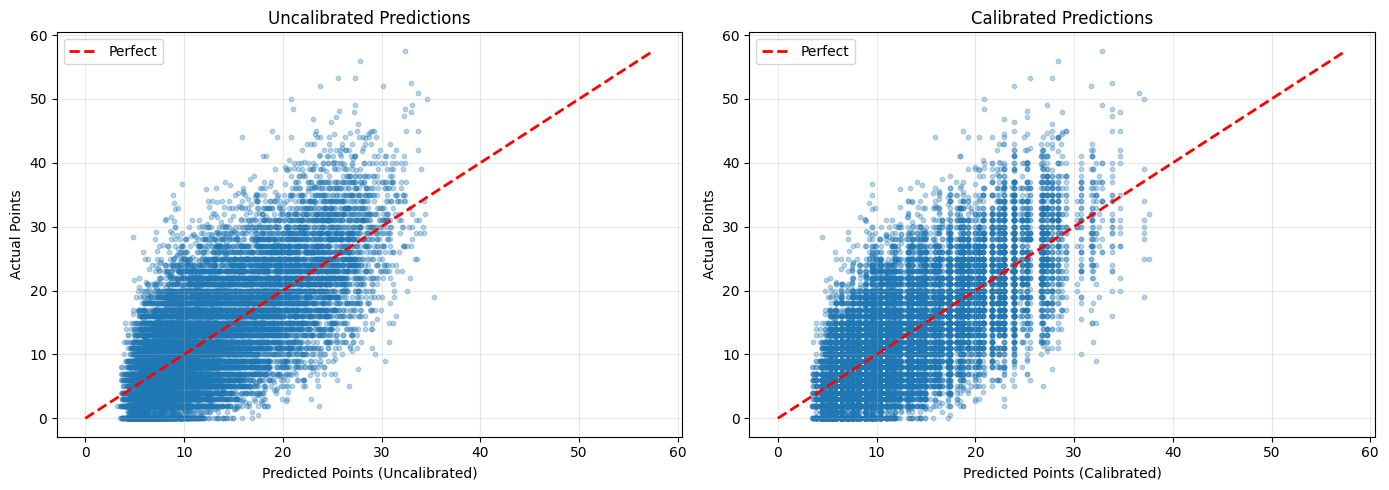

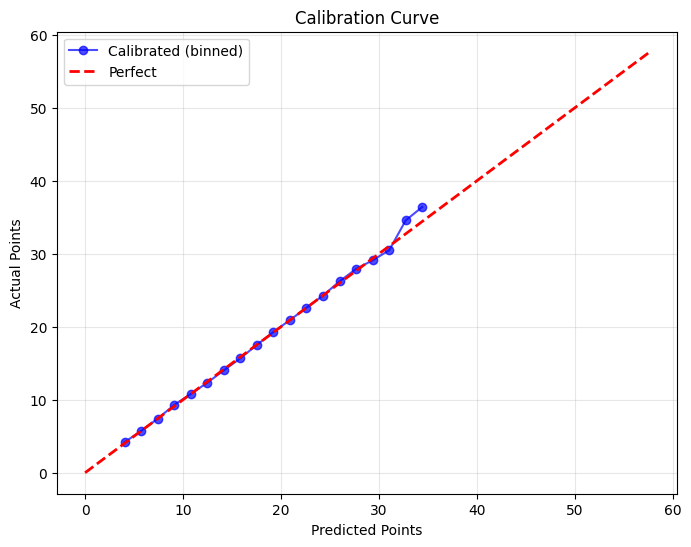

In [24]:
# Visualize calibration: predicted vs actual with calibration line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uncalibrated predictions
axes[0].scatter(y_hat, y_true, alpha=0.3, s=10)
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Predicted Points (Uncalibrated)')
axes[0].set_ylabel('Actual Points')
axes[0].set_title('Uncalibrated Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calibrated predictions
axes[1].scatter(calibrated_preds, y_true, alpha=0.3, s=10)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[1].set_xlabel('Predicted Points (Calibrated)')
axes[1].set_ylabel('Actual Points')
axes[1].set_title('Calibrated Predictions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot calibration curve
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# Bin predictions and compute average actual values
bins = np.linspace(y_hat.min(), y_hat.max(), 20)
bin_indices = np.digitize(y_hat, bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_actuals = [y_true[bin_indices == i].mean() for i in range(1, len(bins))]
bin_preds = [y_hat[bin_indices == i].mean() for i in range(1, len(bins))]

ax.plot(bin_centers, bin_actuals, 'bo-', label='Calibrated (binned)', alpha=0.7)
ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
ax.set_xlabel('Predicted Points')
ax.set_ylabel('Actual Points')
ax.set_title('Calibration Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [25]:
# Apply tier-specific calibration
from MODELS.ngboostModel import predict_mean_with_tier_calibration

# Test on validation set
calibrated_preds = predict_mean_with_tier_calibration(
    model, val_df, top_features
)

# Check new bias by tier
stars = val_df['PTS_ROLLING_AVG_40'] > 20
role = (val_df['PTS_ROLLING_AVG_40'] >= 10) & (val_df['PTS_ROLLING_AVG_40'] <= 20)
bench = val_df['PTS_ROLLING_AVG_40'] < 10

print("=== Bias After Calibration ===")
print(f"Stars:  {(calibrated_preds[stars] - val_df.loc[stars, 'PTS']).mean():+.2f}")
print(f"Role:   {(calibrated_preds[role] - val_df.loc[role, 'PTS']).mean():+.2f}")
print(f"Bench:  {(calibrated_preds[bench] - val_df.loc[bench, 'PTS']).mean():+.2f}")
print(f"Overall: {(calibrated_preds - val_df['PTS']).mean():+.2f}")


ImportError: cannot import name 'predict_mean_with_tier_calibration' from 'MODELS.ngboostModel' (c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\MODELS\ngboostModel.py)

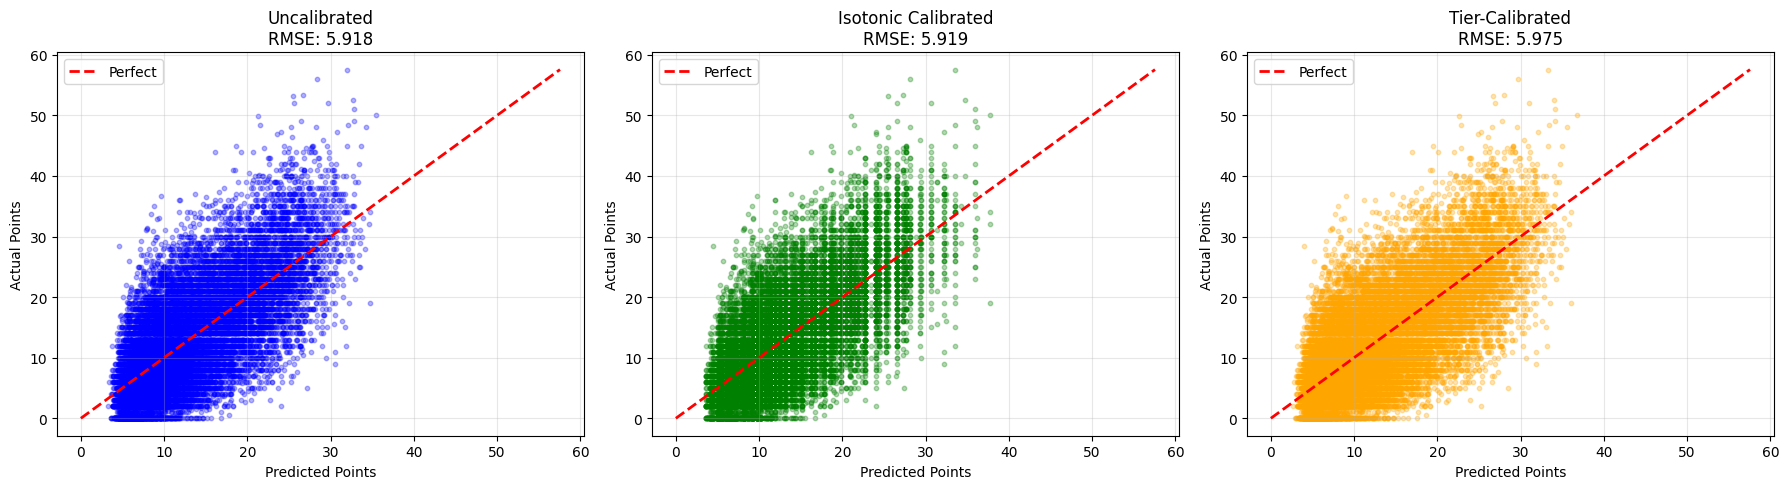

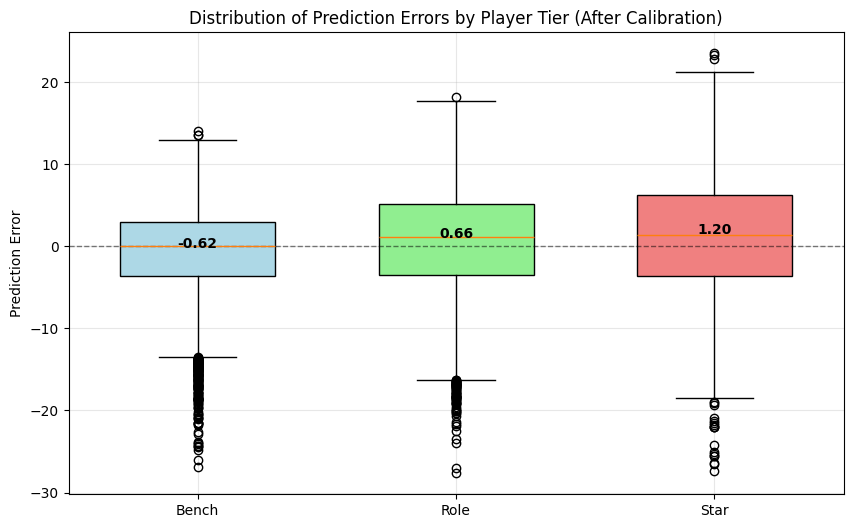

In [25]:
# Visualize all three calibration methods side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Uncalibrated
axes[0].scatter(y_hat, y_true, alpha=0.3, s=10, c='blue')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Predicted Points')
axes[0].set_ylabel('Actual Points')
axes[0].set_title(f'Uncalibrated\nRMSE: {rmse:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Isotonic
axes[1].scatter(calibrated_preds, y_true, alpha=0.3, s=10, c='green')
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[1].set_xlabel('Predicted Points')
axes[1].set_ylabel('Actual Points')
axes[1].set_title(f'Isotonic Calibrated\nRMSE: {calibrated_rmse:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Tier-specific
axes[2].scatter(tier_calibrated_preds, y_true, alpha=0.3, s=10, c='orange')
axes[2].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect')
axes[2].set_xlabel('Predicted Points')
axes[2].set_ylabel('Actual Points')
axes[2].set_title(f'Tier-Calibrated\nRMSE: {tier_cal_rmse:.3f}')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Box plot of errors by tier
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
tier_order = ['Bench', 'Role', 'Star']
val_df_plot = val_df.copy()
val_df_plot['player_tier'] = pd.Categorical(val_df_plot['player_tier'], categories=tier_order)

for i, tier in enumerate(tier_order):
    tier_data = val_df_plot[val_df_plot['player_tier'] == tier]['tier_error'].values
    bp = ax.boxplot(tier_data, positions=[i], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=['lightblue', 'lightgreen', 'lightcoral'][i]))
    ax.text(i, tier_data.mean(), f'{tier_data.mean():.2f}', 
            ha='center', va='bottom', fontweight='bold')

ax.set_xticklabels(tier_order)
ax.set_ylabel('Prediction Error')
ax.set_title('Distribution of Prediction Errors by Player Tier (After Calibration)')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3)
plt.show()


### Plot SHAP values per position to verify the model leans on the right drivers


SHAP ANALYSIS:
------------------------------


c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\shap\explainers\_tree.py:1403: UserWarning: Translating model_output="raw" to model_output=0 for the 0-th parameter in the distribution. Use model_output=0 directly to avoid this warning.
  warnings.warn(


Top 15 Features by SHAP importance:
  PTS_ROLLING_AVG_40             2.4173
  STARTING                       0.7734
  PACE_ADJUSTED_EXPECTED_PTS     0.6626
  TEAM_PTS_ROLLING_AVG_3         0.5083
  PTS_PER_MIN_X_MIN_LAG          0.4481
  STAR_SAT_OUT                   0.3801
  OPP_GUARD_DEF_RATING           0.3631
  FGA_LAG_1                      0.3226
  USG_PCT_AVG_TO_DATE            0.3191
  USG_PCT_ROLLING_AVG_5          0.2238
  MATCHUP_AVG_PTS_LAST_3_TO_DATE 0.2154
  PTS_DELTA_STAR_OUT             0.1911
  PLAYER_IS_TEAM_STAR            0.1768
  USUAL_STARTERS_AVAILABLE       0.1737
  STARTING_X_STARTER_TIER        0.1420


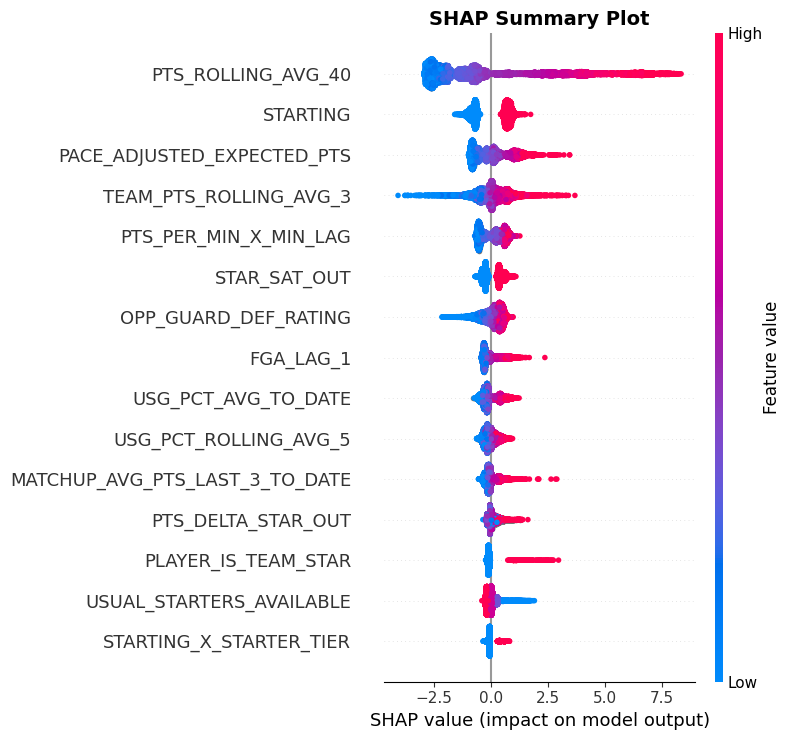

,Dist,<class 'ngboo...ormal.Normal'>
,Score,<class 'ngboo...res.LogScore'>
,Base,DecisionTreeR...r(max_depth=4)
,natural_gradient,True
,n_estimators,500
,learning_rate,0.05
,minibatch_frac,0.7
,col_sample,1.0
,verbose,False
,random_state,RandomState(M... 0x1FD9319F340
,validation_fraction,0.1


In [26]:
analyze_shap(model, val_df, top_features, 'PTS')

In [11]:
# joblib.dump(xgbModel, 'SAVED_MODELS/XGBOOST_PTS_MODEL.pkl')
joblib.dump(model, 'SAVED_MODELS/NGBOOST_PTS_MODEL.pkl')

joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']